<a href="https://colab.research.google.com/github/Maffert/telecom-x-parte-2/blob/main/telecom_x_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recolección de datos 🚀

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/datos_tratados.csv')
df.head()


,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [3]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


# Pre-procesamiento

## Eliminación de Columnas Irrelevantes

In [5]:
df = df.drop(columns=['CustomerID'])
df.head()




,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


## One-hot-encoding

In [6]:
## transformando variables a un formato simple

cols_a_cambiar =  ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_a_cambiar:
  df[col] = df[col].replace({'No internet service': 'No'})

## Revisando valores nulos

In [7]:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# EDA

## Correlación con variables numéricas

In [8]:
df_numerico = df.select_dtypes(include=['int64', 'float64'])
df_numerico.head()

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
0,9,2.19,65.6,593.30
1,9,2.00,59.9,542.40
2,4,2.46,73.9,280.85
3,13,3.27,98.0,1237.85
4,3,2.80,83.9,267.40


In [9]:
#Convirtiendo Churn a numérico
df_numerico['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [10]:
# Matriz de correlación
corr_matrix = df_numerico.corr()
corr_matrix

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,Churn
Tenure,1.000000,0.247910,0.247900,0.826178,-0.352229
ChargesDaily,0.247910,1.000000,0.999996,0.651189,0.193412
ChargesMonthly,0.247900,0.999996,1.000000,0.651174,0.193356
ChargesTotal,0.826178,0.651189,0.651174,1.000000,-0.198324
Churn,-0.352229,0.193412,0.193356,-0.198324,1.000000


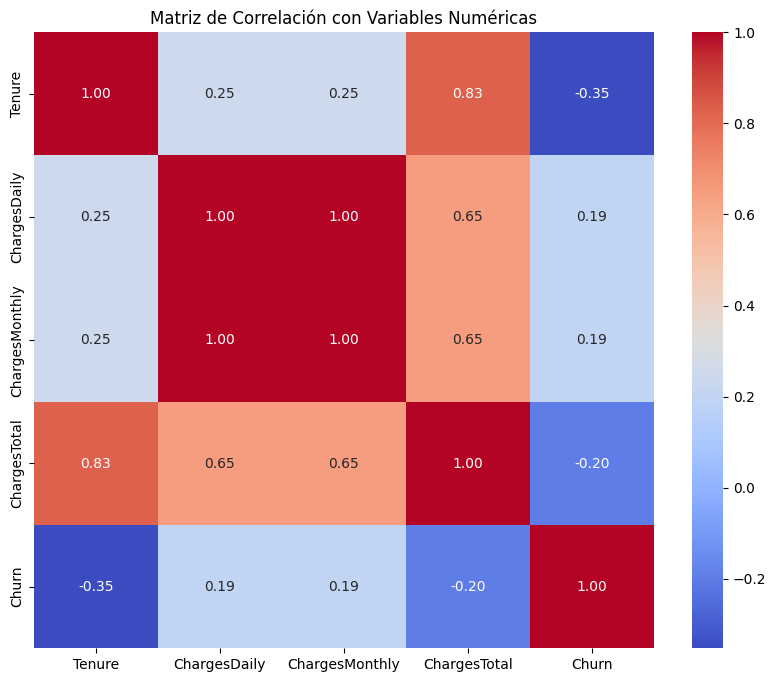

In [11]:
# Visualizando la correlación con Variables Numéricas
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación con Variables Numéricas')
plt.show()

Se observa que Tenure presenta correlación negativa con la cancelación y
ChargesMonthly muestra correlación positiva, sugiriendo que cargos más altos pueden asociarse con mayor cancelación.

## Correlación con variables categoricas

In [12]:
cols_categoricas = df.select_dtypes(include=['object']).columns
cols_categoricas = cols_categoricas.drop('Churn')


In [13]:

# Visualizando la correlación con Variables Categoricas

for col in cols_categoricas:
  print(f"\n Análisis de variable: {col}")
  display(pd.crosstab(df[col], df['Churn'], normalize="index") *100)
  display


 Análisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



 Análisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



 Análisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



 Análisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



 Análisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## Análisis Dirigido

## A) Tiempo de contrato × Cancelación

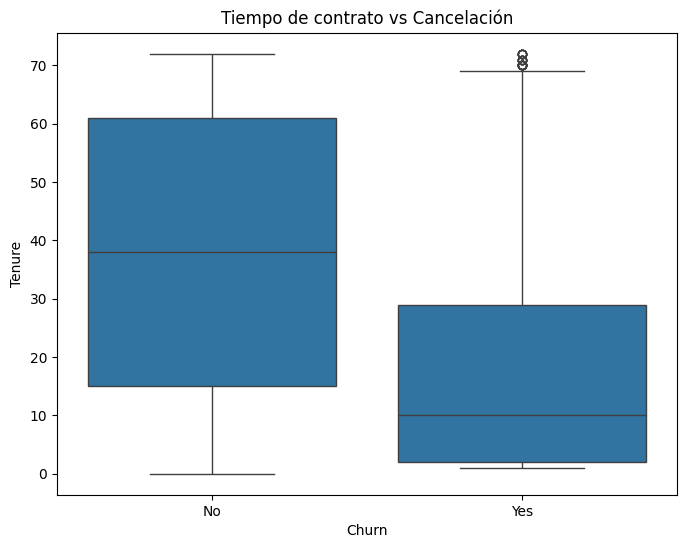

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Tiempo de contrato vs Cancelación')
plt.show()

Los clientes que cancelan tienden a tener menor tiempo de permanencia, indicando mayor riesgo en los primeros meses.

## B) Gasto total × Cancelación

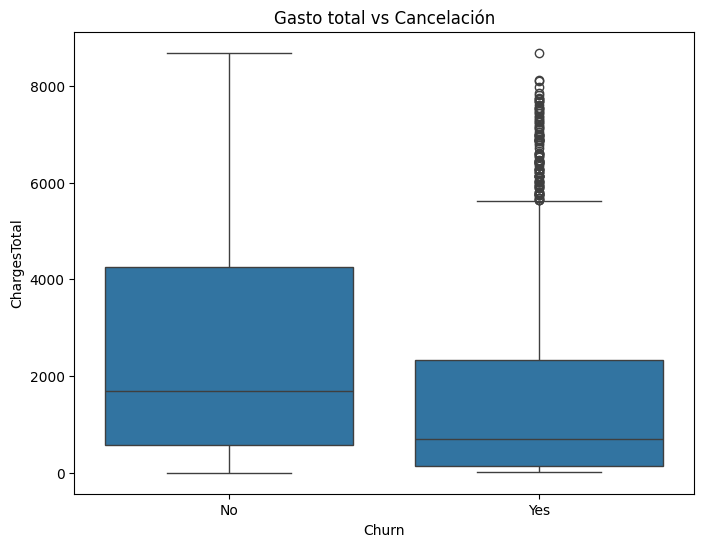

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn', y='ChargesTotal', data=df)
plt.title('Gasto total vs Cancelación')
plt.show()

Clientes con menor gasto acumulado muestran mayor tendencia a cancelar, posiblemente por baja fidelización.

In [ ]:
df = df.drop(columns=['ChargesTotal', 'ChargesDaily'])

## Método Chi-Cuadrado

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2


In [ ]:
#Creación de copia y conversión de Churn a binario

df_rank = df.copy()
df_rank['Churn'] = df_rank['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
# Separación de variables categoricas
cols_categoricas = df_rank.select_dtypes(include=['object']).columns

In [ ]:
# Aplicación de Label Encoding
le = LabelEncoder()
for col in cols_categoricas:
  df_rank[col] = le.fit_transform(df_rank[col])

In [ ]:
# Inicia separación de X, y
X_cat = df_rank[cols_categoricas]
y = df_rank['Churn']

In [ ]:
# Aplicación Chi-Cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Creación de nuevo DF incluyendo rank
chi_df = pd.DataFrame({
    'Variable': cols_categoricas,
    'Chi-Cuadrado': chi_scores,
    'p-value': p_values
})

chi_df = chi_df.sort_values(by='Chi-Cuadrado', ascending=False)
chi_df

,Variable,Chi-Cuadrado,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [ ]:
vars_significant = chi_df[chi_df['p-value'] < 0.05]
print("Ranking Completo")

print("\n Variables significativas (p < 0.05):")
display(vars_significant)


Ranking Completo

 Variables significativas (p < 0.05):


,Variable,Chi-Cuadrado,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [ ]:
#Variables con menor similitud
df = df.drop(columns=["Gender", "PhoneService"])


# Split

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

## Split

In [ ]:
# Separación de datos entre Entreno y Test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## One Hot Encoding

In [ ]:
# One Hot Encoding en Entreno

X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicación en Test
X_test = pd.get_dummies(X_test, drop_first=True)

# Revisión de entreno y test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [ ]:
X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False
3926,33,74.75,False,True,True,False,False,False,True,False,True,False,True,True,True,False,False,True,False,False
3859,14,86.00,False,False,True,True,True,False,True,False,False,True,False,False,False,False,True,False,False,True


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3793 to 5679
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 5634 non-null   int64  
 1   ChargesMonthly                         5634 non-null   float64
 2   SeniorCitizen_Yes                      5634 non-null   bool   
 3   Partner_Yes                            5634 non-null   bool   
 4   Dependents_Yes                         5634 non-null   bool   
 5   MultipleLines_Yes                      5634 non-null   bool   
 6   InternetService_Fiber optic            5634 non-null   bool   
 7   InternetService_No                     5634 non-null   bool   
 8   OnlineSecurity_Yes                     5634 non-null   bool   
 9   OnlineBackup_Yes                       5634 non-null   bool   
 10  DeviceProtection_Yes                   5634 non-null   bool   
 11  TechSu

In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1409 entries, 455 to 5658
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 1409 non-null   int64  
 1   ChargesMonthly                         1409 non-null   float64
 2   SeniorCitizen_Yes                      1409 non-null   bool   
 3   Partner_Yes                            1409 non-null   bool   
 4   Dependents_Yes                         1409 non-null   bool   
 5   MultipleLines_Yes                      1409 non-null   bool   
 6   InternetService_Fiber optic            1409 non-null   bool   
 7   InternetService_No                     1409 non-null   bool   
 8   OnlineSecurity_Yes                     1409 non-null   bool   
 9   OnlineBackup_Yes                       1409 non-null   bool   
 10  DeviceProtection_Yes                   1409 non-null   bool   
 11  TechSup

In [ ]:
# Normalización, revisión de media y desviación
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import numpy as np

print("Media aproximada:", np.mean(X_train_scaled, axis=0)[:5])
print("Desviación aproximada:", np.std(X_train_scaled, axis=0)[:5])

Media aproximada: [-1.89175382e-17  1.84130705e-16  1.89175382e-17  5.29691070e-17
 -7.18866453e-17]
Desviación aproximada: [1. 1. 1. 1. 1.]


## Verificación de desbalanceamiento

In [ ]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
No,73.464679
Yes,26.535321


# Entrenamiento

## Modelo 1 - Regresión Logística

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log_normal = log_model.predict(X_test)

print("Regresión Logística")
print(classification_report(y_test, y_pred_log_normal))

Regresión Logística
              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## Modelo 2 - Árbol Aleatorio

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Árbol Aleatorio")
print(classification_report(y_test, y_pred_rf))

Árbol Aleatorio
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1035
         Yes       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [ ]:
## Balanceando los datos

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

          No       0.90      0.73      0.81      1035
         Yes       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



# Evaluación

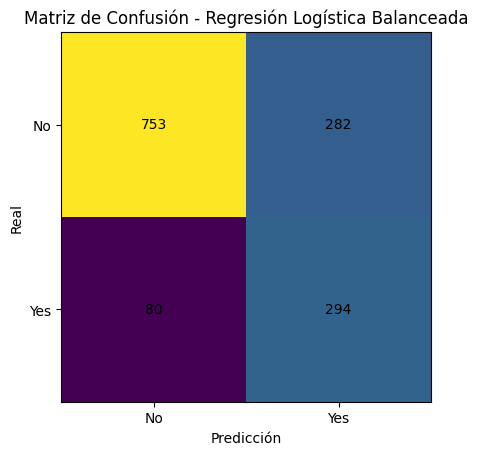

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

#Matriz de Confusión con datos balanceados
cm = confusion_matrix(y_test, y_pred_log)

#Plot
plt.figure()
plt.imshow(cm)
plt.title('Matriz de Confusión - Regresión Logística Balanceada')
plt.xlabel("Predicción")
plt.ylabel("Real")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])
plt.show()

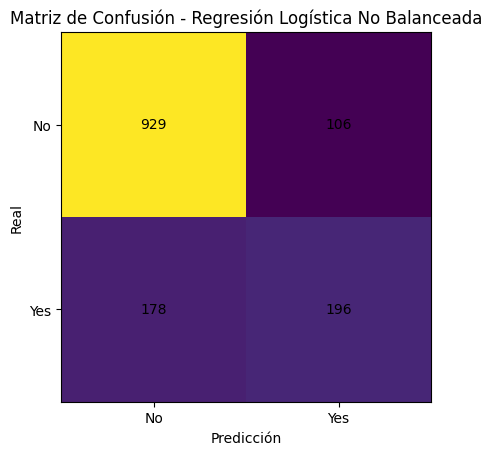

In [ ]:
#Matriz de Confusión con datos normales
cm = confusion_matrix(y_test, y_pred_log_normal)

#Plot
plt.figure()
plt.imshow(cm)
plt.title('Matriz de Confusión - Regresión Logística No Balanceada')
plt.xlabel("Predicción")
plt.ylabel("Real")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["No", "Yes"])
plt.yticks([0,1], ["No", "Yes"])
plt.show()

# Análisis de la Importancia de las Variables

In [ ]:
# coeficientes de variables

feature_names = X_train.columns

coef = log_model.coef_[0]

log_coef_df = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coef,
    'Impacto': np.sign(coef)
}).sort_values(by='Coeficiente', key=abs, ascending=False)

print("Variables más relevantes - Regresión Logística:")
display(log_coef_df)


Variables más relevantes - Regresión Logística:


,Variable,Coeficiente,Impacto
15,Contract_Two year,-1.386755,-1.0
6,InternetService_Fiber optic,1.314570,1.0
7,InternetService_No,-1.294736,-1.0
14,Contract_One year,-0.708311,-1.0
12,StreamingTV_Yes,0.504591,1.0
18,PaymentMethod_Electronic check,0.429403,1.0
13,StreamingMovies_Yes,0.414177,1.0
5,MultipleLines_Yes,0.404301,1.0
16,PaperlessBilling_Yes,0.338989,1.0
11,TechSupport_Yes,-0.265910,-1.0


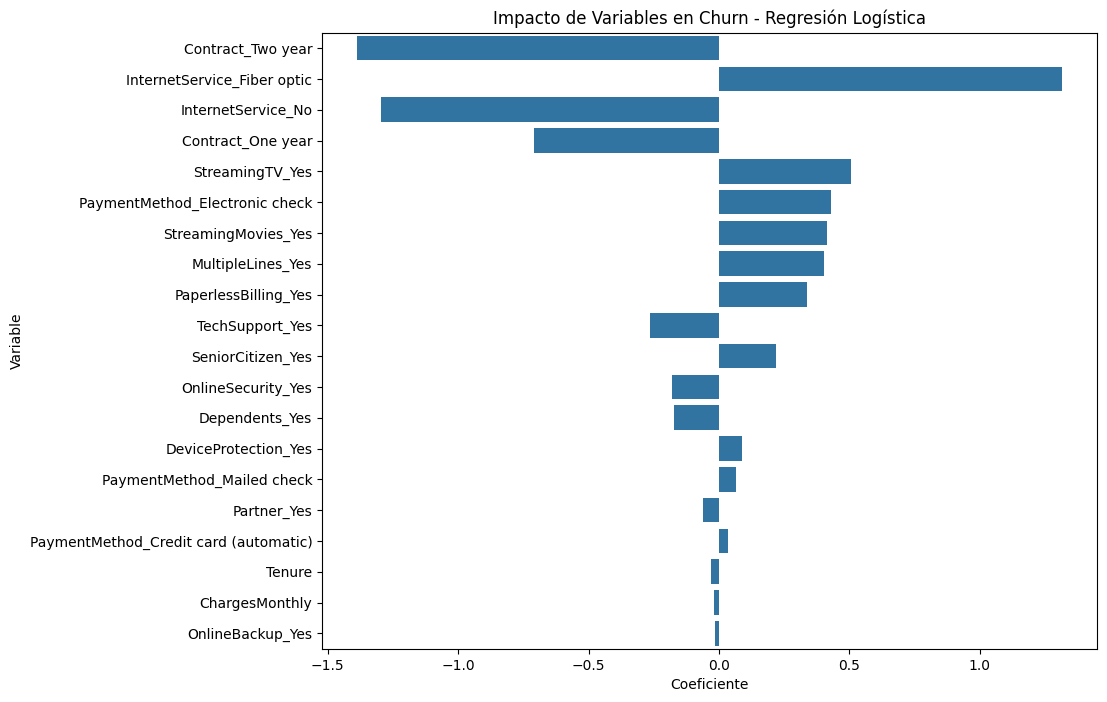

In [ ]:
# gráfico

log_coef_df['Color'] = log_coef_df['Impacto'].map({1:'red', -1:'blue'})

plt.figure(figsize=(10,8))
sns.barplot(
    x='Coeficiente',
    y='Variable',
    data=log_coef_df,
    orient='h'
)

plt.title("Impacto de Variables en Churn - Regresión Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()

Este gráfico muestra cuáles factores influyen más en la cancelación de clientes según el modelo de Regresión Logística. Las barras representan la magnitud del efecto de cada variable; por ejemplo, los contratos largos reducen mucho la probabilidad de cancelar, mientras que tener fibra óptica o usar servicios de streaming se asocia a mayor riesgo de Evasión.


In [ ]:
# Atributos Árbol Aleatorio

rf_importances = rf_model.feature_importances_

rf_imp_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_importances
}).sort_values(by='Importancia', ascending=False)

print("Variables más relevantes - Random Forest:")
display(rf_imp_df)

Variables más relevantes - Random Forest:


,Variable,Importancia
1,ChargesMonthly,0.255088
0,Tenure,0.254962
6,InternetService_Fiber optic,0.046920
18,PaymentMethod_Electronic check,0.042238
15,Contract_Two year,0.041042
16,PaperlessBilling_Yes,0.030306
14,Contract_One year,0.029001
3,Partner_Yes,0.028666
8,OnlineSecurity_Yes,0.027619
9,OnlineBackup_Yes,0.027347


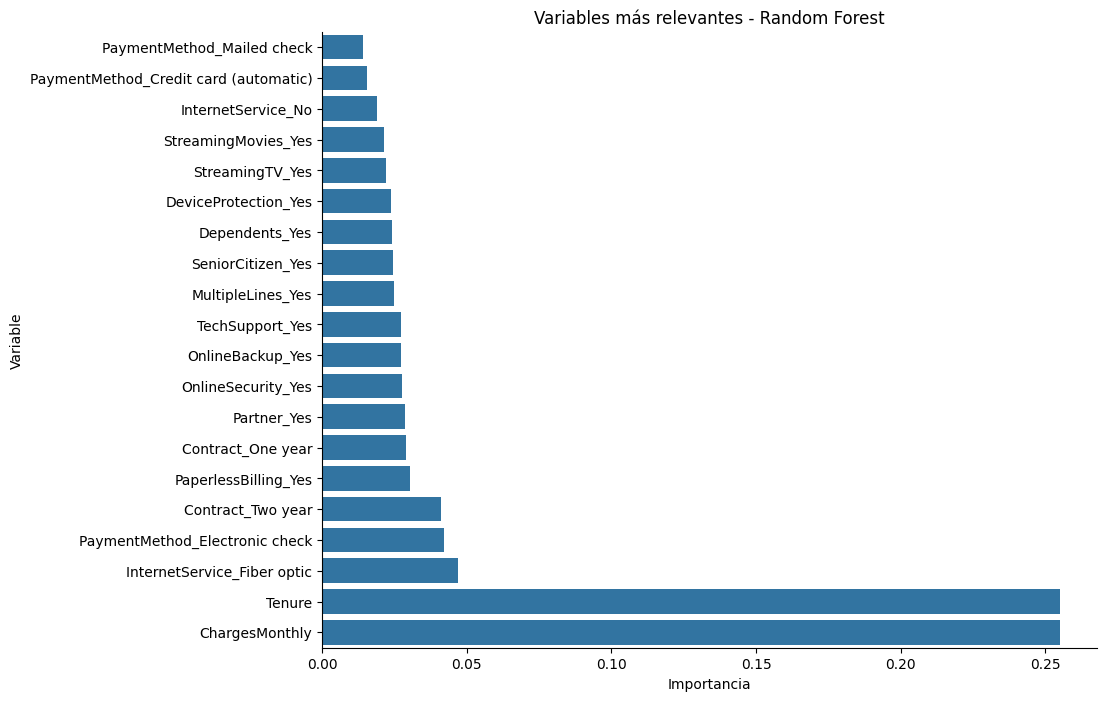

In [ ]:
# Gráfico

plt.figure(figsize=(10,8))

sns.barplot(
    x='Importancia',
    y='Variable',
    data=rf_imp_df.sort_values(by='Importancia', ascending=True),
    orient='h'
)

plt.title("Variables más relevantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
sns.despine()
plt.show()



Según el modelo Random Forest, las variables que más influyen en la predicción de cancelación son ChargesMonthly (0.255) y Tenure (0.255), indicando que el monto mensual y el tiempo que lleva el cliente con el servicio son los factores más determinantes.

# Informe Final – Análisis de Cancelación de Clientes 📊

## Objetivo 🎯

Identificar las variables que influyen en la cancelación de clientes (Churn) y evaluar modelos predictivos que permitan anticipar qué clientes tienen mayor probabilidad de abandonar el servicio.

## Preprocesamiento de Datos 📑

- Eliminamos columnas irrelevantes para evitar ruido en los modelos y mejorar la calidad del entrenamiento.

  ``` python
    df = df.drop(columns=['CustomerID'])
  ```


- Revisamos Valores Nulos, así evitamos que los modelos no fallaran por datos incompletos.
  ``` python
    df.isnull().sum()
  ```

## Análisis Exploratorio de Datos (EDA) 📈




Generamos correlaciones con:

Variables numéricas, la cual nos indica que:
- Existe relación entre el tiempo de permanencia (Tenure) y el gasto total.
- No se ven correlaciones extremadamente altas que puedan indicar multicolinealidad.

Variables Categóricas, la cual notamos:
- Variables con menos impacto como Gender y PhoneService
- Variables con impacto medio y de alto impacto como SeniorCitizen, lo que lleva a que los adultos mayores tienen casi el doble de probabilidad de cancelar.



Realizamos un Análisis Dirigido entre:

    - Tiempo de contrato x Cancelación:
    Los clientes que más cancelan son los que tienen menor promedio de permanencia.
    
    Por lo tanto los primeros meses son críticos para lograr una retención.

    - Gasto Total x Cancelación:
    Los clientes que cancelan tienden a tener menor gasto total.
    Los clientes con mayor inversión son los que tienen a permanecer.

    Por lo tanto el nivel de compromiso en el gasto influye en una permanencia.


Aplicamos la prueba Chi-Cuadrado para seleccionar las variables más significativas con respecto a la variable de destino Churn.

Las variables con un p-valor menor a 0.05 se consideraron significativas y fueron seleccionadas para el modelo.

## Split 🔀

Continuamos realizando un ***split***. El conjunto de datos fue dividido en Entrenamiento y prueba, asegurando que ambas partes tuvieran una proporción representativa de clientes que cancelan (Churn).

- Para las variables categóricas que no podían ser procesadas directamente por los modelos, se utilizó **One Hot Encoding** para crear variables binarias, como:
```python
  X_train = pd.get_dummies(X_train, drop_first=True)
  X_test = pd.get_dummies(X_test, drop_first=True)
```

- Para Regresión Logística, que es sensible a la escala de las variables, se aplicó normalización mediante StandardScaler.

``` python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
```
- Para mantener la distribución de clases balanceada revisamos:

```python
  y_train.value_counts(normalize=True) * 100
```



## Entrenamiento de Modelos 📊

Modelo 1:
**Regresión Logística**

Métricas obtenidas:
```
| Clase | Precision | Recall | F1-Score |
| ----- | --------- | ------ | -------- |
| No    | 0.84      | 0.90   | 0.87     |
| Yes   | 0.65      | 0.52   | 0.58     |

```
**Accuracy general: 80%**

🔎 Hallazgos clave:

El modelo identifica bien a los clientes que no cancelan, pero el recall es bajo en la clase "Yes" (clientes que cancelan), lo que significa que el modelo tiene dificultades para detectar correctamente a los clientes que abandonan.

Modelo 2:
**Random Forest**

Métricas obtenidas:

```
| Clase | Precision | Recall | F1-Score |
| ----- | --------- | ------ | -------- |
| No    | 0.83      | 0.90   | 0.86     |
| Yes   | 0.62      | 0.48   | 0.54     |

```
**Accuracy general: 78%**

🔎 Hallazgos clave:

Al igual que la regresión logística, el modelo tiene un recall bajo para la clase "Yes", lo que significa que también tiene dificultades para identificar a los clientes que cancelan.

Modelo Balanceado:
Para mejorar el recall en la clase "Yes" (clientes que cancelan), aplicamos el parámetro class_weight='balanced' en la Regresión Logística. Esto ajusta el modelo para que dé más peso a la clase minoritaria (churn).

| Clase | Precision | Recall | F1-Score |
| ----- | --------- | ------ | -------- |
| No    | 0.90      | 0.73   | 0.81     |
| Yes   | 0.51      | 0.79   | 0.62     |

**Accuracy general: 74%**

🔎 Hallazgos clave:

El recall de la clase "Yes" sube significativamente de 0.52 a 0.79, lo que indica que ahora el modelo puede identificar mejor a los clientes en riesgo de churn.

Aunque la precisión general baja, el modelo es mucho más efectivo para detectar a los clientes que cancelan. Esto es muy útil para acciones preventivas de retención.


## Evaluación de Variables 🔎

💡**Regresión Logística – Variables más relevantes**

*   Contract_Two year (-1.386) → Los contratos largos reducen la probabilidad de churn.
*   InternetService_Fiber optic (1.315) → Los clientes con fibra óptica tienen mayor riesgo de churn.
*   StreamingTV_Yes (0.505) y PaymentMethod_Electronic check (0.429) también aumentan el riesgo de cancelación.

💡**Random Forest – Variables más relevantes**
*   ChargesMonthly (0.255) → Mayor gasto mensual está asociado con un mayor
riesgo de churn.
*   Tenure (0.255) → Clientes con menos tiempo en la compañía tienen más probabilidad de cancelar.
*   Contract_Two year (0.041) y PaymentMethod_Electronic check (0.042) también tienen relevancia, aunque menor.

## Conclusiones y Recomendaciones 🌟

🚨 Mejor modelo para retención:

La Regresión Logística balanceada es el modelo más adecuado para predecir churn, ya que tiene una mayor capacidad para identificar a los clientes que probablemente cancelarán, a pesar de una ligera reducción en precisión.

🎯 Recomendaciones Estratégicas

*   Ofrecer contratos a largo plazo 📝
*   Mejorar los servicios adicionales 🔧
*   Optimizar las opciones de pago 💳
*   Atraer a clientes jóvenes 👩‍💻


